# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Python Course/Module 1 /Project 1/foodhub_order 1.csv') # this code reads the csv file referenced in the parenthesis.

In [ ]:
df.head() # this code returns the first 5 rows in the dataset.

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [ ]:
df.tail() # this code returns the last 5 rows in the dataset.

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31
1897,1478056,120353,Blue Ribbon Sushi,Japanese,19.45,Weekend,Not given,28,24


#### Observations:



* *There are 9 columns in the data*

* *It seems that all entries in the data are shown except for some cells in the rating column, which are shown as 'Not given'. This would have to be verified*

### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
df.shape # to check the number of rows and columns in the data

(1898, 9)

#### Observations:

*  *There are 1898 rows and 9 columns in the data.*

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
df.info() # this code checks the datatype of each column in addition to display the total rows and columns, and the memory usage.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:

* *All the columns have 1898 observations.*

* *There are 4 numerical columns (columns with index 0, 1, 7, and 8), 4 object type columns (columns with index 2, 3, 5, and 6) and 1 float type column (column with index 4).*

* *The rating column should be float data type however, it is indicated here as object (string) datatype.*

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
df['rating'].unique() # this code checks and returns each unique value in the data.

array(['Not given', '5', '3', '4'], dtype=object)

In [ ]:
df['rating'] = df['rating'].replace('Not given', np.nan) # this code replaces all the 'Not given' entries in the data with NaN

In [ ]:
df.isnull().sum() # this code returns the sum after replacing all the values in the data with the boolean values 'True' if there are missing values such as NAN or none
                  # essentially it returns the sum of null values in the data.

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,736
food_preparation_time,0
delivery_time,0


In [ ]:
df.isnull().sum()[df.isnull().sum() > 0]/df.shape[0]*100 # this code returns the percentage of missing values in the data.

,0
rating,38.777661


#### Observations:

* *First, it was observed that the rating column contained missing values indicated by 'Not given'.*
* *This was changed to 'nan' in order to get the count of the missing values (736).*
* *About 38.77% of the entries in the rating column are missing*
* *There are no missing values in the other columns*
* *Considering the datatype of the rating column, it would be appropriate to treat the missing values using the mean or the median however there are some factors to consider.*
  * *The count of missing values (736) is close to 50% of the total entries, hence it is believed that using the mean or median will likely cause skewness in the data and affect any further analysis.*
  * *In addition, food and restaurant ratings are subjective and reflect each individual's preference and inputting values may be a poor reflection the customer's choice.*
* *Hence treatment of the missing values will be done after further exploration and analysis of the data with respect to the rating column.*

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
df.describe().T # this code returns descriptive statistics of the data and transposes them by swapping the rows and columns for easy readability.

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


#### Observations:

* *Cost of the Orders*
  * *The cost of the orders range from a minimum of 4.47 dollars to a maximum 35.41 dollars.*
  * *The average cost of the order is about 16.49 dollars. About 25% of the orders cost 12.08 dollars and below and about 75% cost 22.29 dollars and below.*


* *Food Preparation Time*
  * *The minimum amount of time it takes for the food to be prepared is 20 minutes, while the maximum about of time is 35 minutes.*
  
* *Delivery Time*
  * *After the food is picked up, it takes a mininum of 15 minutes and a maximum of 33 minutes to be delivered.*
  * *On average, it takes about 25 minutes for the food to be delivered
  *Longer or shorter delivery times may be due to several factors including the distance between the restaurant and the delivery location, however that information is not provided in the data.*

### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
df.isnull().sum() # this code returns the sum of null values in the data.

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,736
food_preparation_time,0
delivery_time,0


#### Observations:

* *736 orders are not rated.*

* *This could be accounted for by:
  * *Either the customers did not rate these orders or there were errors when the data was being compiled.*

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

#### **Customer ID**

In [ ]:
df['customer_id'].nunique() # this code counts and returns the total number of unique values in the customer ID column.

1200

In [ ]:
df['customer_id'].value_counts() # this code checks and returns the frequency of each unique value in the customer ID column.

,count
customer_id,
52832,13
47440,10
83287,9
250494,8
259341,7
...,...
143926,1
89574,1
157711,1


#### Observations:

* *There are 1200 entries out of 1898 rows in the customer_id column. This seems to suggest that there are repeat customers.*

* *Customer 528832 made the highest number of orders - 13.*

### **CATEGORICAL DATA**

#### **Restaurant Name**

In [ ]:
df['restaurant_name'].nunique() # this code counts and returns the total number of unique values in the restaurant name column.

178

In [ ]:
df['restaurant_name'].value_counts() # this code checks and returns the frequency of each unique value in the restaurant name column.

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68
...,...
Rye House,1
Hiroko's Place,1
Frank Restaurant,1


#### Observations:

* *There are 178 out of 1898 rows in the restaurant_name column. This seems to suggest that some of the restaurants received multiple orders from the customers*

* *The restaurant with the highest order of 219 was Shake Shack*

#### **Cuisine Type**

In [ ]:
df['cuisine_type'].nunique() # this code counts and returns the total number of unique values in the cuisine type column.

14

In [ ]:
df['cuisine_type'].value_counts() # this code checks and returns the frequency of each unique value in the cuisine type column.

,count
cuisine_type,
American,584
Japanese,470
Italian,298
Chinese,215
Mexican,77
Indian,73
Middle Eastern,49
Mediterranean,46
Thai,19


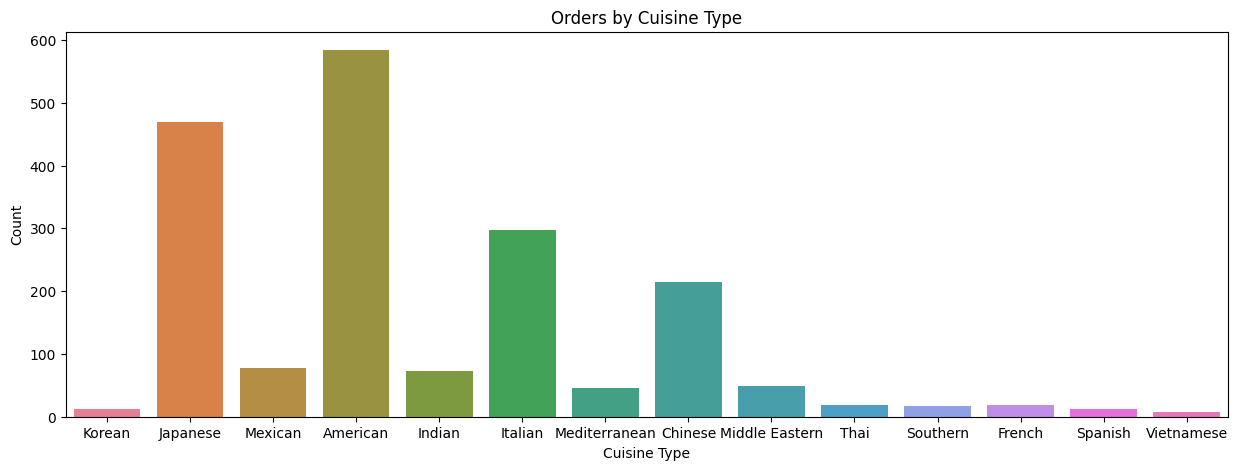

In [ ]:
plt.figure(figsize= (15,5)) # this code create a plot with the size 15,5.
sns.countplot(x = 'cuisine_type', data = df, hue = 'cuisine_type') # this code creates a count plot using the cuisine type column of the dataframe 'df' with each bar having a different color.
plt.title('Orders by Cuisine Type') # this code sets the title of the count plot as specified in the parenthesis.
plt.xlabel('Cuisine Type') # this code sets the label on the x axis as 'Cuisine Type'
plt.ylabel('Count') # this code sets the label on the y axis as 'Count'.
plt.show() # this code displays the count plot.

#### Observations:

* *There are 14 types of cuisine in the data.*

* *Customer seems to order more American cuisine than any other type of cuisine.*

* *The least order cuisine is Vietnamese.*

#### **Day of the Week**

In [ ]:
df['day_of_the_week'].value_counts() # this code counts and returns the total number of unique values in the day of the week column.

,count
day_of_the_week,
Weekend,1351
Weekday,547


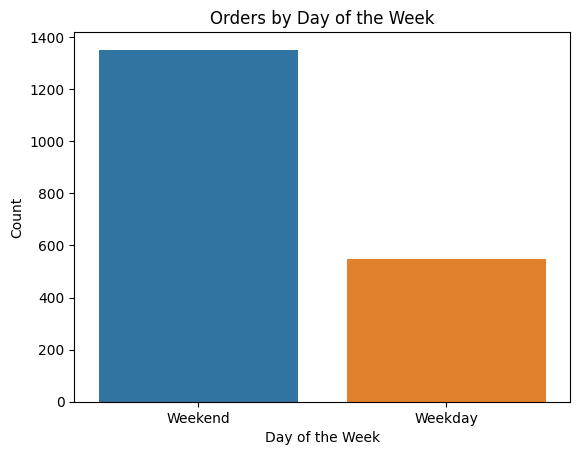

In [ ]:
sns.countplot(x = 'day_of_the_week', data = df, hue = 'day_of_the_week') # this code creates a count plot using the day of the week column of the dataframe 'df' with each bar having a different color.
plt.title('Orders by Day of the Week') # this code sets the title of the count plot as specified in the parenthesis.
plt.xlabel('Day of the Week') # this code sets the label on the x axis as 'Day of the Week'
plt.ylabel('Count') # this code sets the label on the y axis as 'Count'.
plt.show() # this code displays the count plot.

#### Observations:

* *More orders were placed on the weekend than on weekdays.*

###**NUMERICAL DATA**

#### **Cost of the Order**

In [ ]:
df['cost_of_the_order'].value_counts() # # this code checks and returns the frequency of each unique value in the cost of the order column.

,count
cost_of_the_order,
12.18,86
12.13,82
12.23,47
24.20,42
29.10,37
...,...
7.66,1
10.86,1
7.95,1


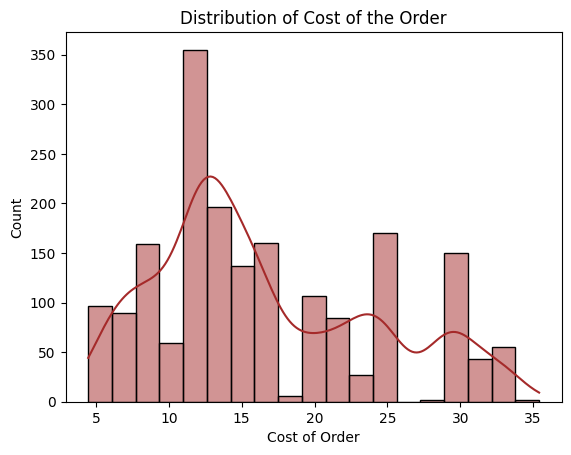

In [ ]:
sns.histplot(df['cost_of_the_order'], kde = True, color = 'brown') # this code creates a histogram with the cost of the order column of the dataframe df, displays the curve (kde) and the bars in brown.
plt.title('Distribution of Cost of the Order') # this sets the title of the histogram as specified in the parenthesis.
plt.xlabel('Cost of Order') # this labels the x axis as 'Cost of Order'.
plt.ylabel('Count') # this labels the y axis as 'Count'
plt.show() # this displays the histogram

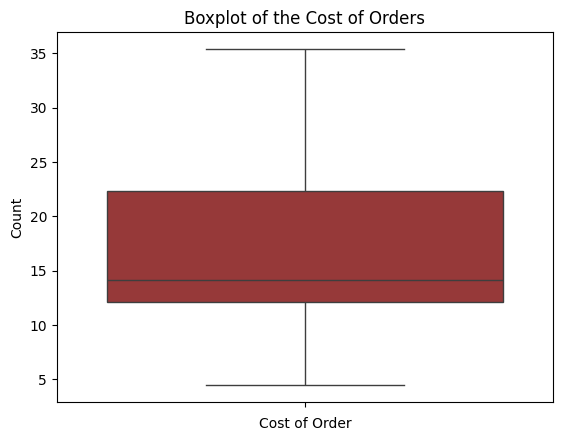

In [ ]:
sns.boxplot(df['cost_of_the_order'], color = 'brown') # this code creates a box plot with the cost of the order column in the dataframe df, setting the color to brown.
plt.title('Boxplot of the Cost of Orders') # this sets the title of the boxplot as specified in the parenthesis.
plt.xlabel('Cost of Order') # this labels the x axis as 'Cost of Order'
plt.ylabel('Count') # this labels the y axis as 'Count'
plt.show() # this displays the box plot.

#### Observations:

* *There are no outliers present in the cost_of_the_order column.*

* *The median is about 14 dollars.*

* *The data seems to be slightly right skewed with more orders costing around 12 dollars.*

#### **Food Preparation Time**

In [ ]:
df['food_preparation_time'].value_counts() # this code checks and returns the frequency of each unique value in the food preparation time column.

,count
food_preparation_time,
21,135
23,123
27,123
22,123
28,121
24,121
30,119
20,119
33,118


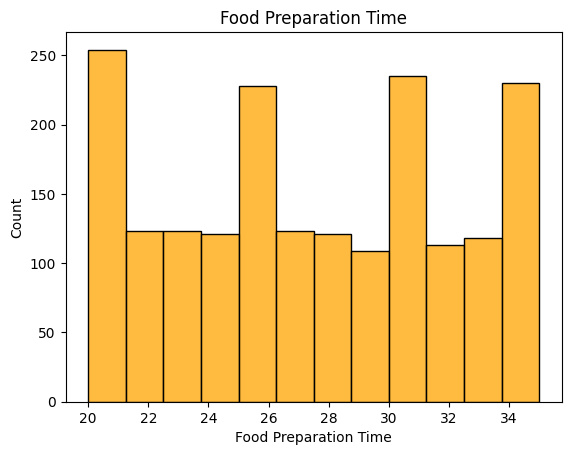

In [ ]:
sns.histplot(df['food_preparation_time'], color = 'orange') # this code creates a histogram with the Food Preparation Time column of the dataframe df, displaying the bars in orange.
plt.title('Food Preparation Time') # this sets the title of the histogram as specified in the parenthesis.
plt.xlabel('Food Preparation Time') # this labels the x axis as 'Food Preparation Time'.
plt.ylabel('Count') # this labels the y axis as 'Count'
plt.show() # this displays the histogram

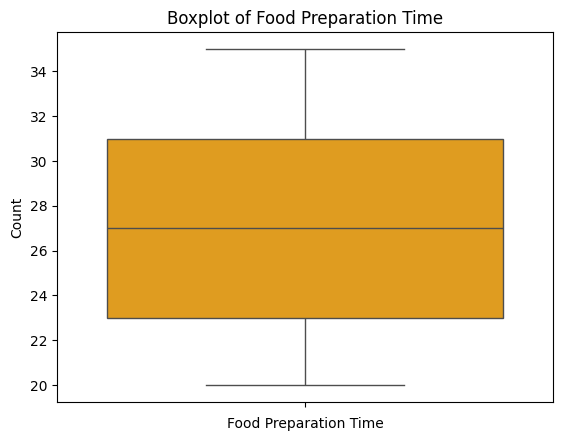

In [ ]:
sns.boxplot(df['food_preparation_time'], color = 'orange') # this code creates a box plot with the food preparation time column in the dataframe df, setting the color to orange.
plt.title('Boxplot of Food Preparation Time') # this sets the title of the boxplot as specified in the parenthesis.
plt.xlabel('Food Preparation Time') # this labels the x axis as 'Food Preparation Time'
plt.ylabel('Count') # this labels the y axis as 'Count'
plt.show() # this displays the box plot.

#### Observations:

* *Based on the boxplot, the data in the food_preparation_time column seems to be evenly distributed with no outliers.*

* *There are 4 peak times(based on the histplot), that is between 20-21 minutes, 25-26 minutes, 30-31 minutes and 34 minutes. These were the most common times it took for orders to be prepared.*

#### **Delivery Time**

In [ ]:
df['delivery_time'].value_counts() # # this code checks and returns the frequency of each unique value in the delivery time column.

,count
delivery_time,
24,162
29,148
28,148
26,141
27,138
30,133
25,120
19,90
16,90


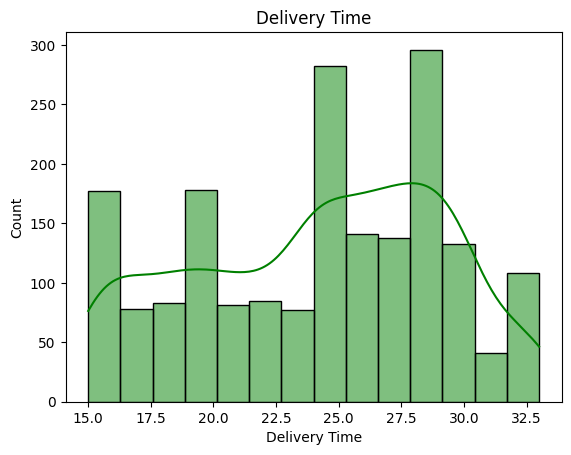

In [ ]:
sns.histplot(df['delivery_time'], kde = True, color = 'green') # this code creates a histogram with the Delivery Time column of the dataframe df, displaying the bars in green.
plt.title('Delivery Time') # this sets the title of the histogram as specified in the parenthesis.
plt.xlabel('Delivery Time') # this labels the x axis as 'Delivery Time'.
plt.show() # this displays the histogram

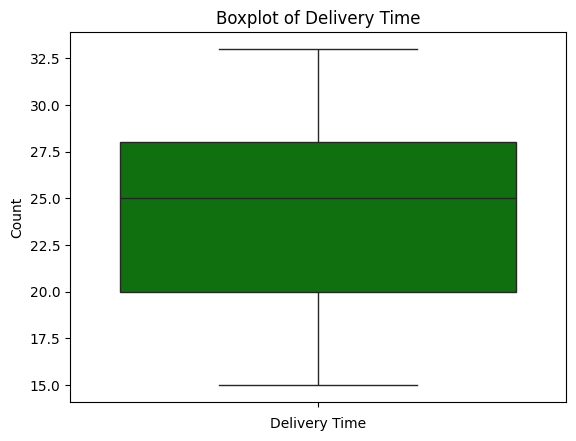

In [ ]:
sns.boxplot(df['delivery_time'], color = 'green') # this code creates a box plot with the delivery time column in the dataframe df, setting the color to green.
plt.title('Boxplot of Delivery Time') # this sets the title of the boxplot as specified in the parenthesis.
plt.xlabel('Delivery Time') # this labels the x axis as 'Delivery Time'
plt.ylabel('Count') # this labels the y axis as 'Count'
plt.show() # this displays the box plot.

#### Observation:

* *There are no outliers in the data.*

* *A lot more orders were delivered between 28 and 29 minutes.*

* *There are 4 peak delivery times. These are between 15-16 minutes, 19-20 minutes, 24.5-25 minutes and 28-29 minutes.*

#### **Rating**

In [ ]:
df['rating'].value_counts() # this code checks and returns the frequency of each unique value in the rating column.

,count
rating,
5,588
4,386
3,188


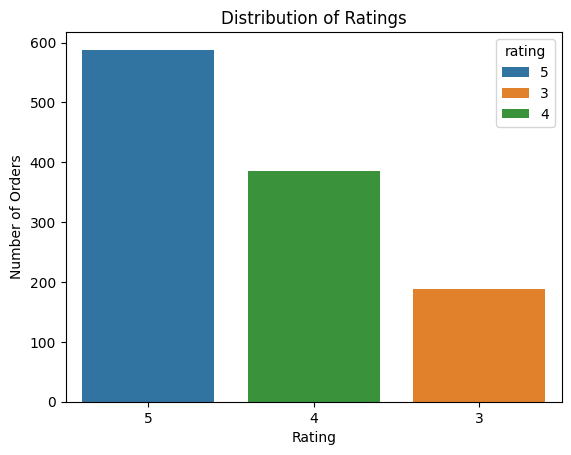

In [ ]:
sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, hue='rating') # this code creates a count plot with the Rating column of the dataframe df, displaying each unique value against the total number of orders.
plt.title('Distribution of Ratings') # this sets the title of the histogram as specified in the parenthesis.
plt.xlabel('Rating') # this labels the x axis as 'Rating'
plt.ylabel('Number of Orders') # this labels the y axis as 'Number of Orders'
plt.show() # this displays the histogram

#### Observation:

* *Since the missing values in the rating column were changed to nan, they do not appear when checking for the frequency of each unique value*

* *It was observed earlier that, 736 of the orders were not rated. This represents close to 50% of all entries for the ratings column.*

* *The orders were rated between 3 and 5.*

* *More orders were rated 5 as compared to 3 and 4.*

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
df['restaurant_name'].value_counts().head(5) # this code counts and displays the total number of unique values of the top 5 restaurants

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


In [ ]:
top_5_restaurants = df['restaurant_name'].value_counts().nlargest(5).index # this code stores the 5 of the restaurants with the most orders in the variable 'top_5_restaurants'.


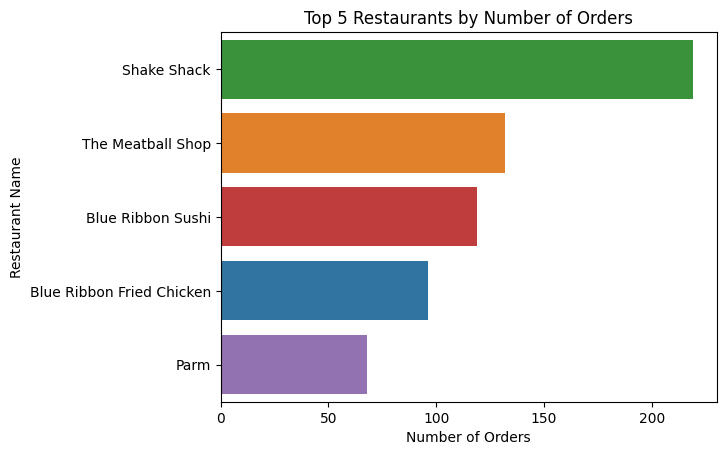

In [ ]:
sns.countplot(data=df[df['restaurant_name'].isin(top_5_restaurants)], y='restaurant_name', order=top_5_restaurants, hue='restaurant_name') # this code creates a count plot of the top 5 restaurants in terms of number of orders received.
plt.title('Top 5 Restaurants by Number of Orders') # this sets the title of the count plot as 'Top 5 Restaurants by Number of Orders'.
plt.xlabel('Number of Orders') # this labels the x axis as 'Number of Orders'.
plt.ylabel('Restaurant Name') # this labels the y axis as 'Restaurant Name'.
plt.show() # this displays the count plot.

#### Observations:

* The top 5 restaurants that received the most orders are
  * Shake Shack with the highest number of orders 219
  * The Meatball Shop 132
  * Blue Ribbon Sushi 119
  * Blue Ribbon Fried Chicken 96
  * Parm 68

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
df_weekend = df[df['day_of_the_week'] == 'Weekend'] # this code checks and stores all the entries that correspond to 'Weekend' in the variable 'df_weekend'.
df_weekend['cuisine_type'].value_counts() # his code checks and returns the frequency of each unique value of the dataframe 'df_weekend'.

,count
cuisine_type,
American,415
Japanese,335
Italian,207
Chinese,163
Mexican,53
Indian,49
Middle Eastern,32
Mediterranean,32
Thai,15


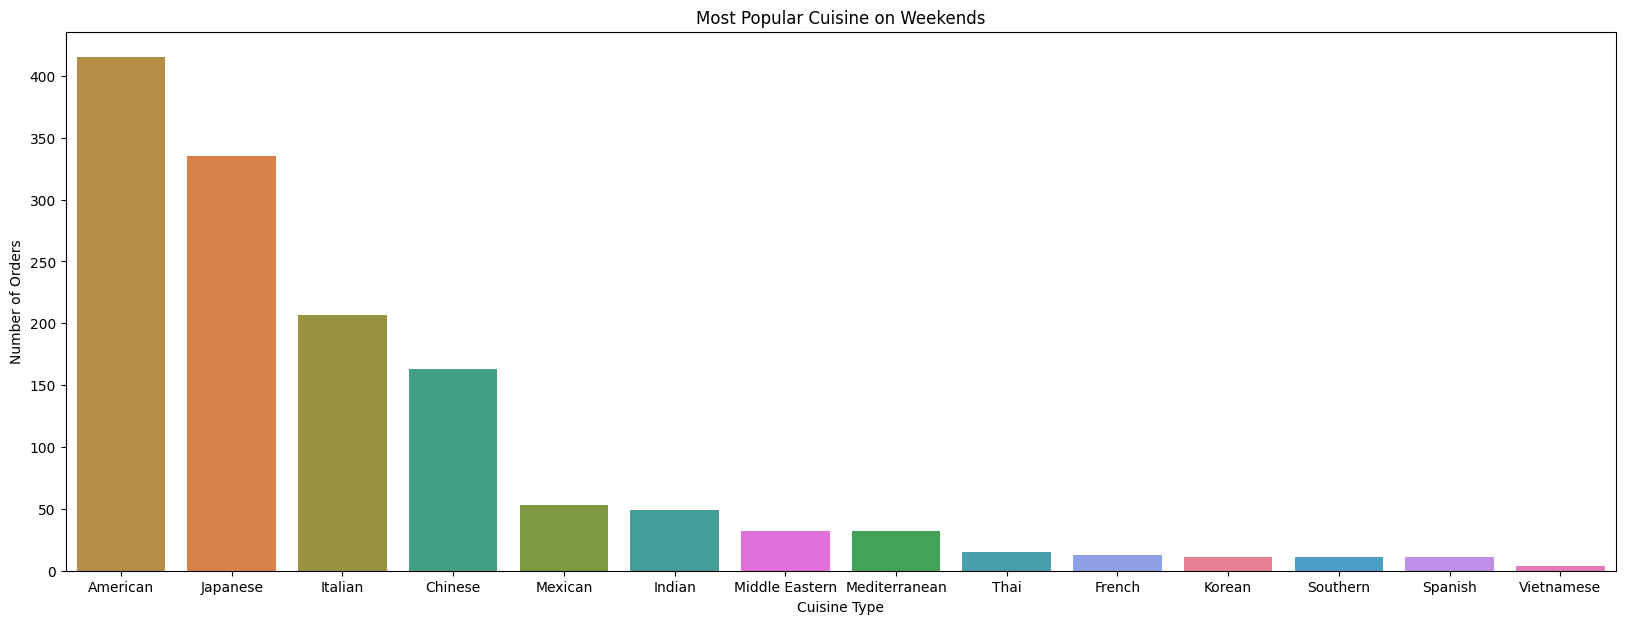

In [ ]:
plt.figure(figsize=(20, 7)) # this code creates a plot with the size 20,7.
sns.countplot(data=df_weekend, x='cuisine_type', order=df_weekend['cuisine_type'].value_counts().index, hue='cuisine_type') # this code creates a count plot of the most popular cuisine on weekends.
plt.title('Most Popular Cuisine on Weekends') # this sets the title of the count plot as 'Most Popular Cuisine on Weekends'.
plt.xlabel('Cuisine Type') # this labels the x axis as 'Cuisine Type'.
plt.ylabel('Number of Orders') # this labels the y axis as 'Number of Orders'.
plt.show() # this displays the count plot.

#### Observations:

* The most popular cuisine on weekends are American, Japanese, Italian and Chinese.
  * American cuisine recorded the highest number, of 415 orders.  
  * Japanese cuisine recorded the second highest number, of 335 orders.
  * Italian cuisine recorded the third highest number, of 207 orders.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
df_greater_than_20 = df[df['cost_of_the_order'] > 20] # this code creates a dataframe of orders costing more than 20 dollars and stores it in the variable 'df_greater_than_20'
percentage_greater_than_20 = (len(df_greater_than_20) / len(df)) * 100 # this code calculates the percentage of orders costing more than 20 dollars and stores it in the variable 'percentage_greater_than_20'
percentage_greater_than_20 = round(percentage_greater_than_20, 2) # this code rounds the percentage to 2 decimal places and stores it in the variable 'percentage_greater_than_20'
percentage_greater_than_20 # this code prints the percentage of orders costing more than 20 dollars

29.24

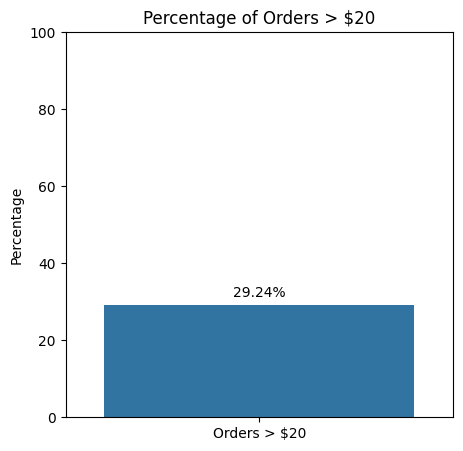

In [ ]:
plt.figure(figsize=(5, 5)) # this creates a plot with size 5, 5.
sns.barplot(x=['Orders > $20'], y=[percentage_greater_than_20]) # this code create a bar plot of 'Orders > $20' on the x-axis and the calculated percentage on the y-axis.
plt.title('Percentage of Orders > $20') # this sets the title of the plot as specified in the parenthesis.
plt.ylabel('Percentage') # this labels the y-axis as 'Percentage'.
plt.ylim(0, 100) # this limits the the y-axis from 0 to 100.
plt.text(0, percentage_greater_than_20 + 2, f'{percentage_greater_than_20}%', ha='center') # this places the percentage value at the top of the bar.
plt.show() # this displays the bar plot.

#### Observations:

* *29.24% of the orders cost more than $20.00.*
* *This seems to represent approximately more than a quarter of the data.*

### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
delivery_time_mean = df['delivery_time'].mean() # this code calculates the mean of the delivery time column and stores it in the variable 'delivery_time_mean'
delivery_time_mean = round(delivery_time_mean, 2) # this code rounds the mean to 2 decimal places and stores it in the variable 'delivery_time_mean'
delivery_time_mean # this code prints the mean value of the delivery time.

np.float64(24.16)

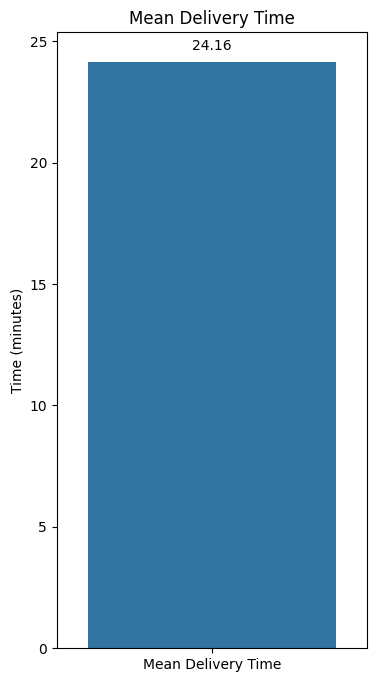

In [ ]:
plt.figure(figsize=(4, 8)) # this creates a plot with size 4, 8.
sns.barplot(x=['Mean Delivery Time'], y=[delivery_time_mean]) # # this code create a bar plot of 'Mean Delivery Time' on the x-axis and the calculated mean on the y-axis.
plt.title('Mean Delivery Time') # this sets the title of the plot as specified in the parenthesis.
plt.ylabel('Time (minutes)') # this labels the y-axis as 'Time(minutes)'.
plt.text(0, delivery_time_mean + 0.5, f'{delivery_time_mean:.2f}', ha='center') # # this places the mean value on top of the bar.
plt.show() # this displays the plot.

#### Observations:

* *It takes about 24 minutes and 16 seconds to delivery the food package after it has been pickedup by the delivery person.*

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
top_3_customers = df['customer_id'].value_counts().head(3) # this code counts and displays the total number of unique values of the top 3 customers. The output is stored in the variable 'top_3_customers'.

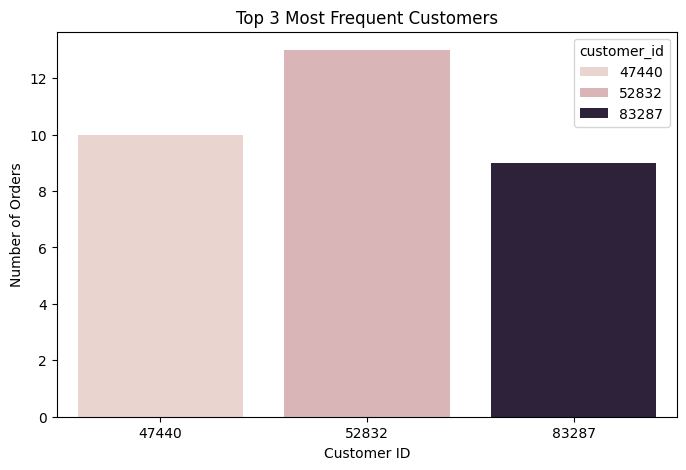

In [ ]:
plt.figure(figsize=(8, 5)) # this creates a plot with size 8, 5.
sns.barplot(x=top_3_customers.index, y=top_3_customers.values, hue=top_3_customers.index) # this code create a bar plot of customer IDs on the x-axis and order counts on the y-axis.
plt.title('Top 3 Most Frequent Customers') # this sets the title of the plot as specified in the parenthesis.
plt.xlabel('Customer ID') # # this labels the x axis as 'Customer ID'
plt.ylabel('Number of Orders') # this labels the y axis as 'Number of Orders'
plt.show() # this displays the plot.

#### Observations:

* *The most frequent customer in the dataset made 13 orders. That is, customer with ID number 52832.*

* *This was closely followed by customer with ID number 47440 with 10 orders.*
* *This was also closely followed by customer with ID number 83287 with 9 orders.*

* *These are the 3 most frequent customers who will be awarded the 20% discount voucher.*

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


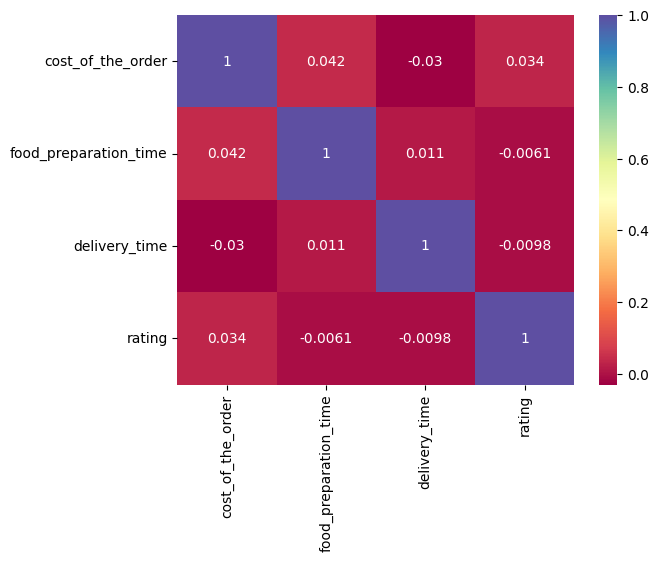

In [ ]:
sns.heatmap(data=df[['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'rating']].corr(), annot=True, cmap = 'Spectral'); # this code creates a heatmap of the correlation between the 4 variables specified.

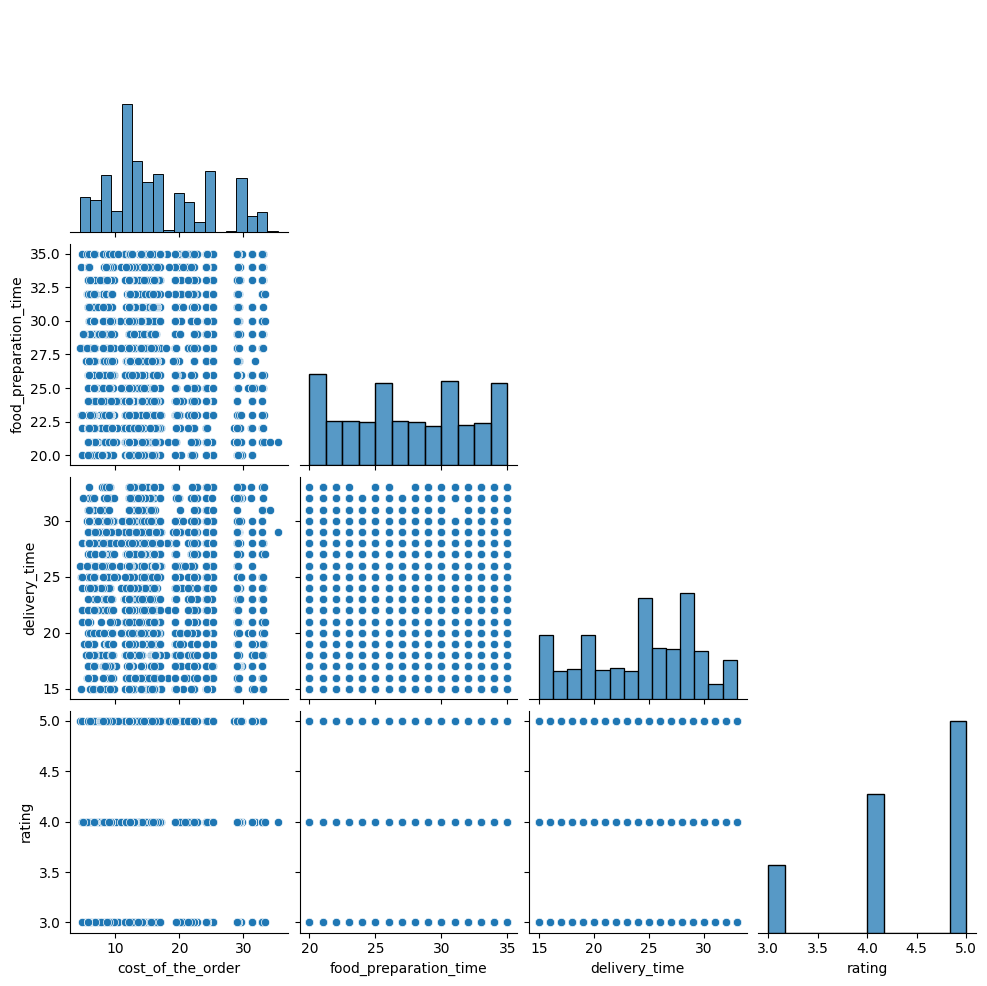

In [ ]:
sns.pairplot(df[['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'rating']], corner=True); # this code creates a pairplot of the 4 variables specified and displays the bottom half of the plot.

#### Observation:

* *There seems to be little to no correlation between cost of the order, food preparation time, delivery time and rating.*

*Cuisine Type vs Cost of the Order*

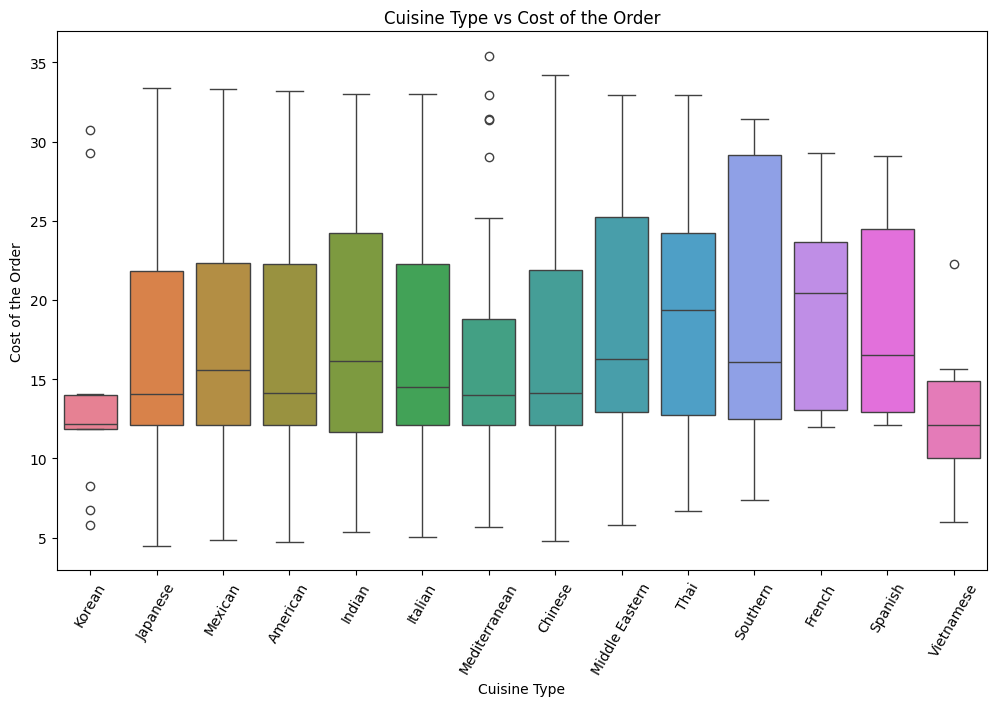

In [ ]:
plt.figure(figsize=(12,7))
sns.boxplot(x = 'cuisine_type', y = 'cost_of_the_order', data = df, hue = 'cuisine_type')
plt.title('Cuisine Type vs Cost of the Order')
plt.xlabel('Cuisine Type')
plt.ylabel('Cost of the Order')
plt.xticks(rotation = 60)
plt.show()
# this code creates a box plot of the cuisine type and cost of the order

#### Observation:

* *There are outliers in the cost of order for Korean, Mediterranean and Vietnamese cuisines.*

* *Vietnamese cuisine seems to cost less than all other cuisines.*

* *The most expensive cuisines are Thai and French which have the highest average cost.*

#### Cuisine Type and Food preparation Time

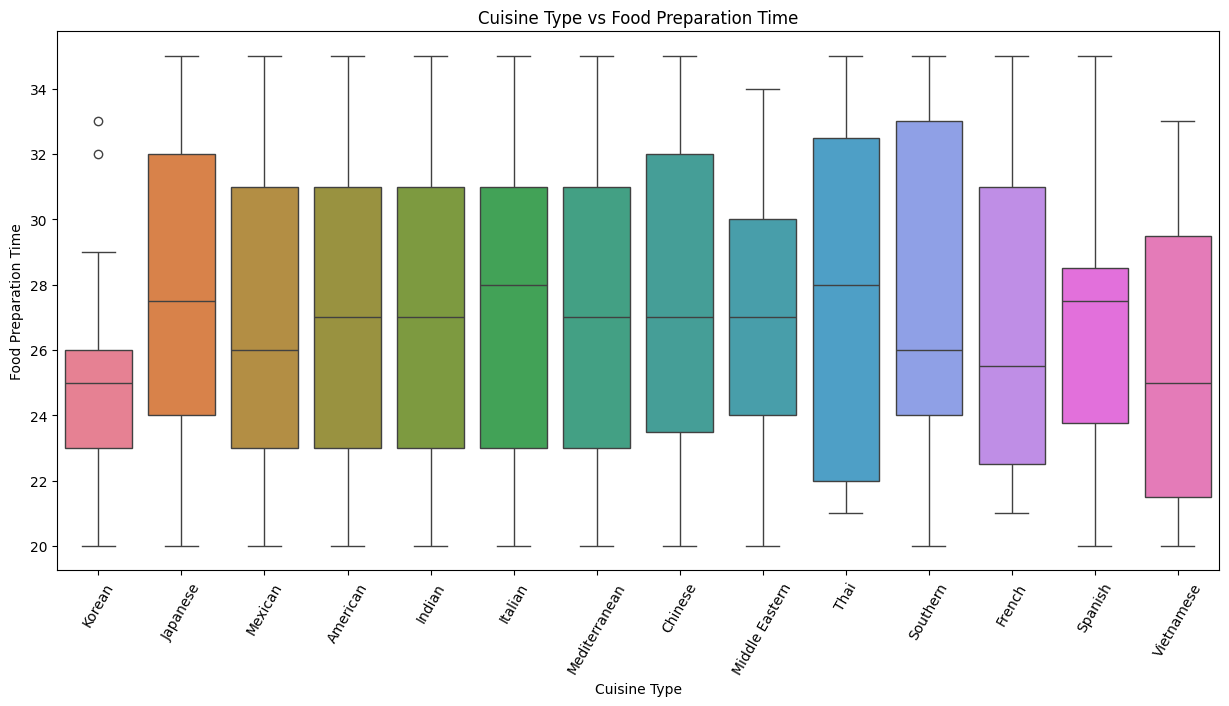

In [ ]:
plt.figure(figsize=(15,7))
sns.boxplot(x = 'cuisine_type', y = 'food_preparation_time', data = df, hue = 'cuisine_type')  ## Complete the code to visualize the relationship between food preparation time and cuisine type using boxplot
plt.title('Cuisine Type vs Food Preparation Time')
plt.xlabel('Cuisine Type')
plt.ylabel('Food Preparation Time')
plt.xticks(rotation = 60)
plt.show()
# this code creates a box plot of the cuisine type and food preparation time

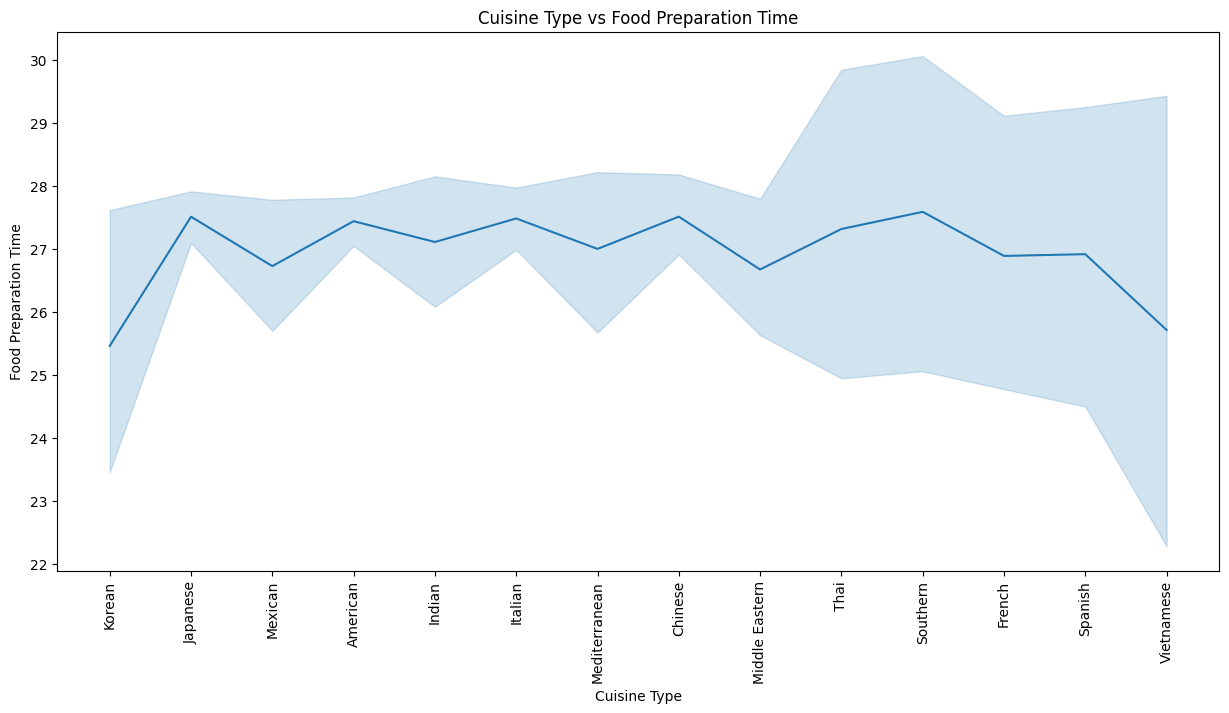

In [ ]:
plt.figure(figsize=(15,7))
sns.lineplot(data=df, x='cuisine_type', y='food_preparation_time')
plt.title('Cuisine Type vs Food Preparation Time')
plt.xlabel('Cuisine Type')
plt.ylabel('Food Preparation Time')
plt.xticks(rotation=90)
plt.show()
# this code creates a line plot of the cuisine type and food preparation time

#### Observation:

* *Korean cuisine takes the least time to prepare.*

* *Spanish, Thai, Italian and Japenese take averagely more time to prepare than the other cuisines.*

#### Day of the Week and Cost of Order

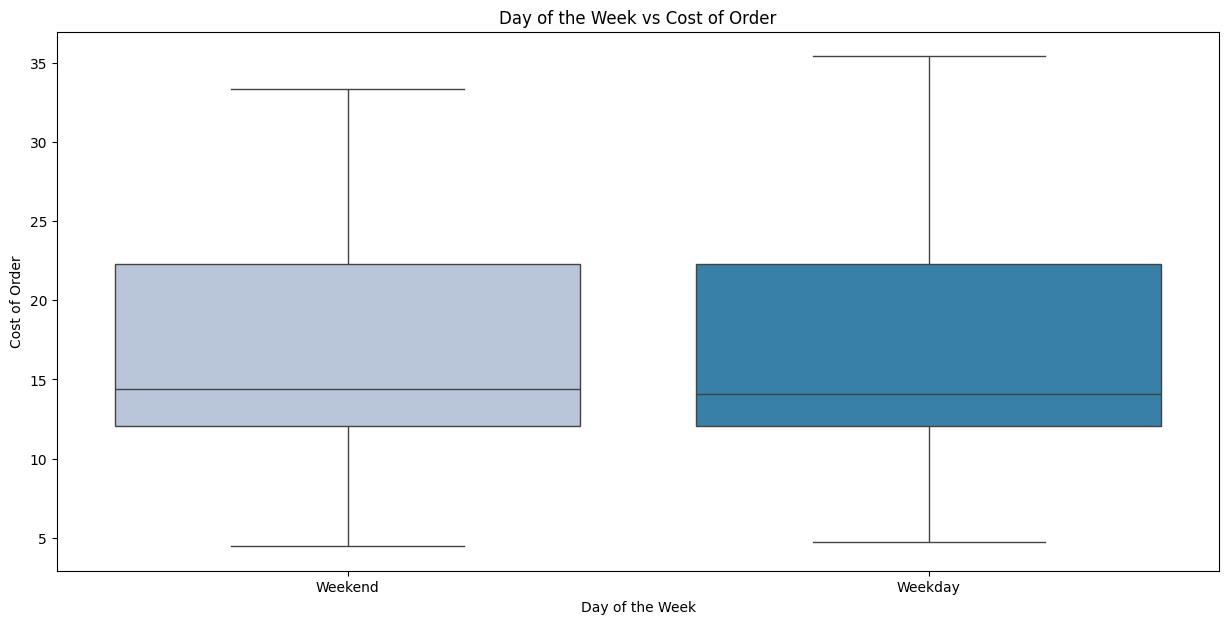

In [ ]:
plt.figure(figsize=(15,7))
sns.boxplot(x = 'day_of_the_week', y = 'cost_of_the_order', data = df, palette = 'PuBu', hue = 'day_of_the_week')  ## Complete the code to visualize the relationship between day of the week and delivery time using boxplot
plt.title('Day of the Week vs Cost of Order')
plt.xlabel('Day of the Week')
plt.ylabel('Cost of Order')
plt.show()
# this code creates a box plot of the day of the week and the cost of the order

#### Observation:

* *On average, there is no difference in the cost of the order on weekday and weekends*



#### Day of the Week and Delivery Time

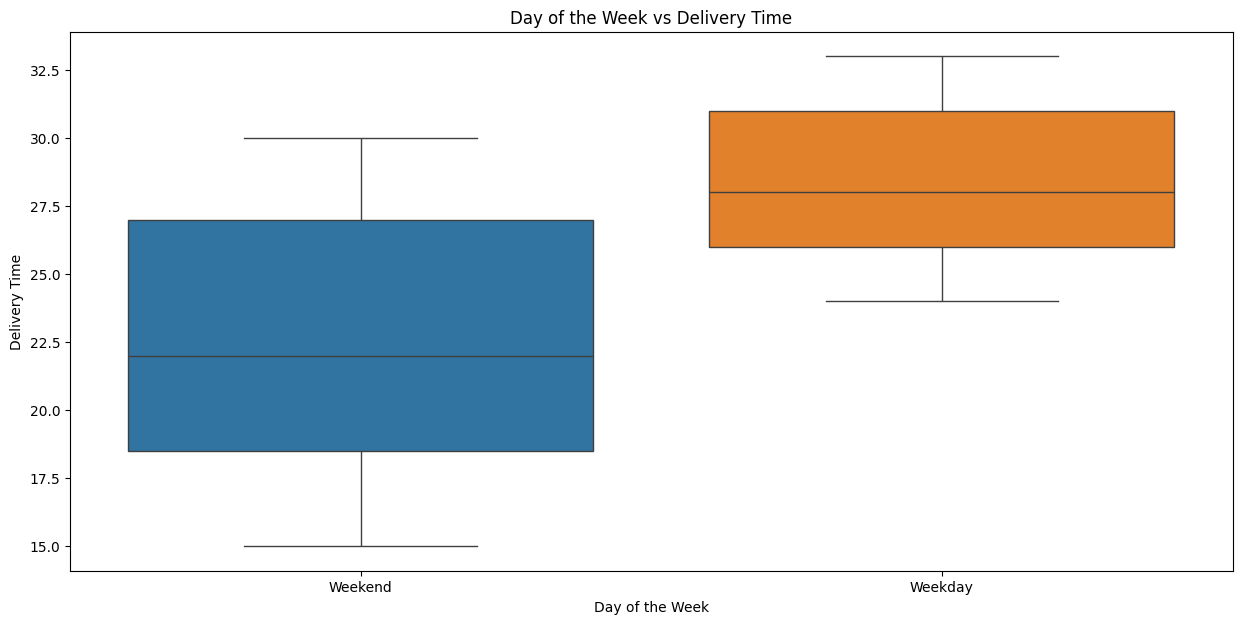

In [ ]:
plt.figure(figsize=(15,7))
sns.boxplot(x = 'day_of_the_week', y = 'delivery_time', data = df, hue = 'day_of_the_week')  ## Complete the code to visualize the relationship between day of the week and delivery time using boxplot
plt.title('Day of the Week vs Delivery Time')
plt.xlabel('Day of the Week')
plt.ylabel('Delivery Time')
plt.show()
# this code creates a box plot of the day of the week and the delivery time

#### Observation:

* *Orders take longer to be delivered on weekdays than on weekends*

#### Day of the Week and Food Preparation Time

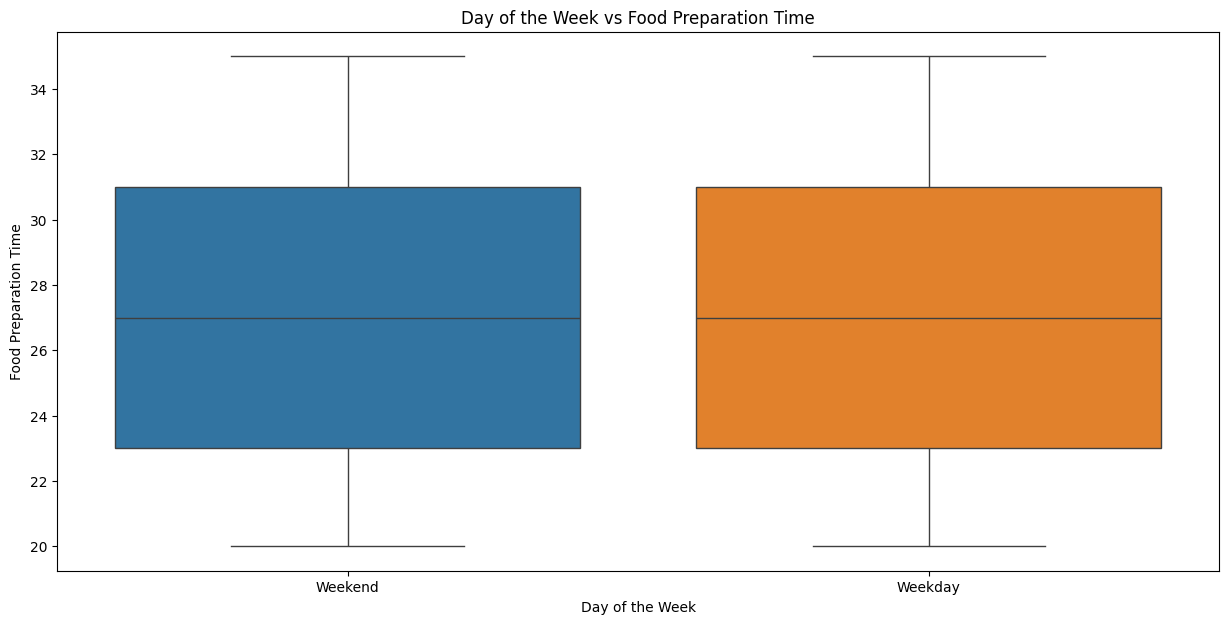

In [ ]:
plt.figure(figsize=(15,7))
sns.boxplot(x = 'day_of_the_week', y = 'food_preparation_time', data = df, hue = 'day_of_the_week')  ## Complete the code to visualize the relationship between day of the week and delivery time using boxplot
plt.title('Day of the Week vs Food Preparation Time')
plt.xlabel('Day of the Week')
plt.ylabel('Food Preparation Time')
plt.show()
# this code creates a box plot of the day of the week and the food preparation time

#### Observation:

* *The average time it takes to prepare the food does not vary for the two categories of the day of the week.*

* *It takes approximately the same time to prepare the food on both weekdays and weekends.*, there is no difference in the food p*


#### Rating and Cuisine Type

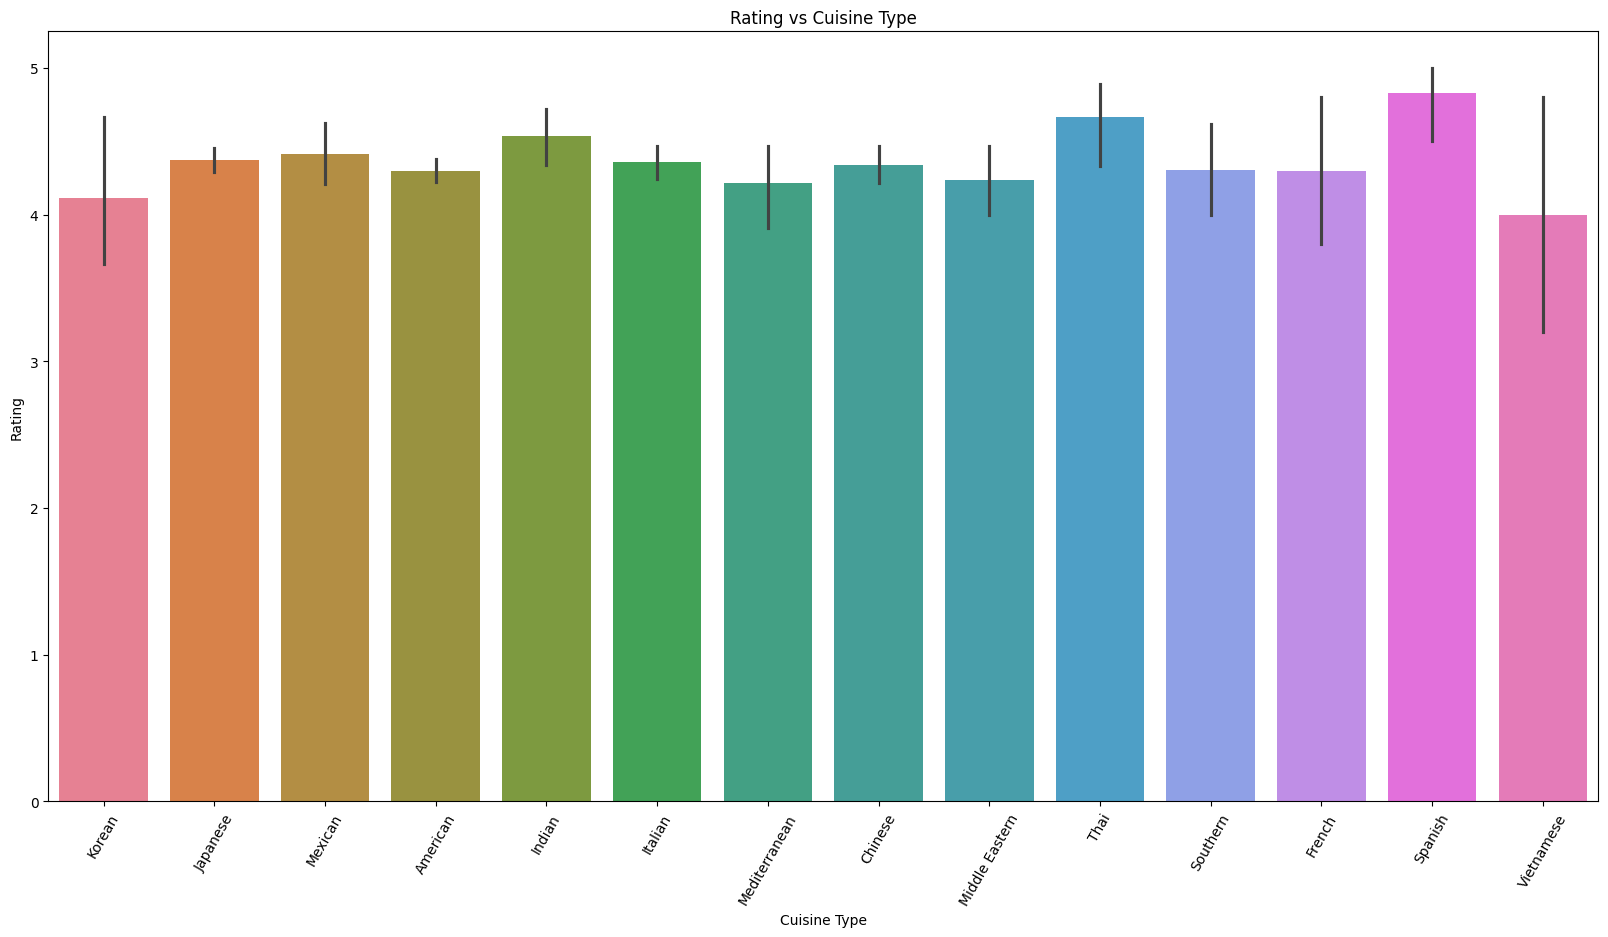

In [ ]:
plt.figure(figsize=(20,10))
sns.barplot(x = 'cuisine_type', y = 'rating', data=df, hue='cuisine_type')
plt.title('Rating vs Cuisine Type')
plt.xlabel('Cuisine Type')
plt.ylabel('Rating')
plt.xticks(rotation = 60)
plt.show()
# this code creates a bar plot of the rating and the cuisine type

#### Observation:

* *There are no cuisines with extremely low ratings.*

* *Spanish, Thai and Indian cuisines have higher ratings.*

#### Rating and Delivery Time

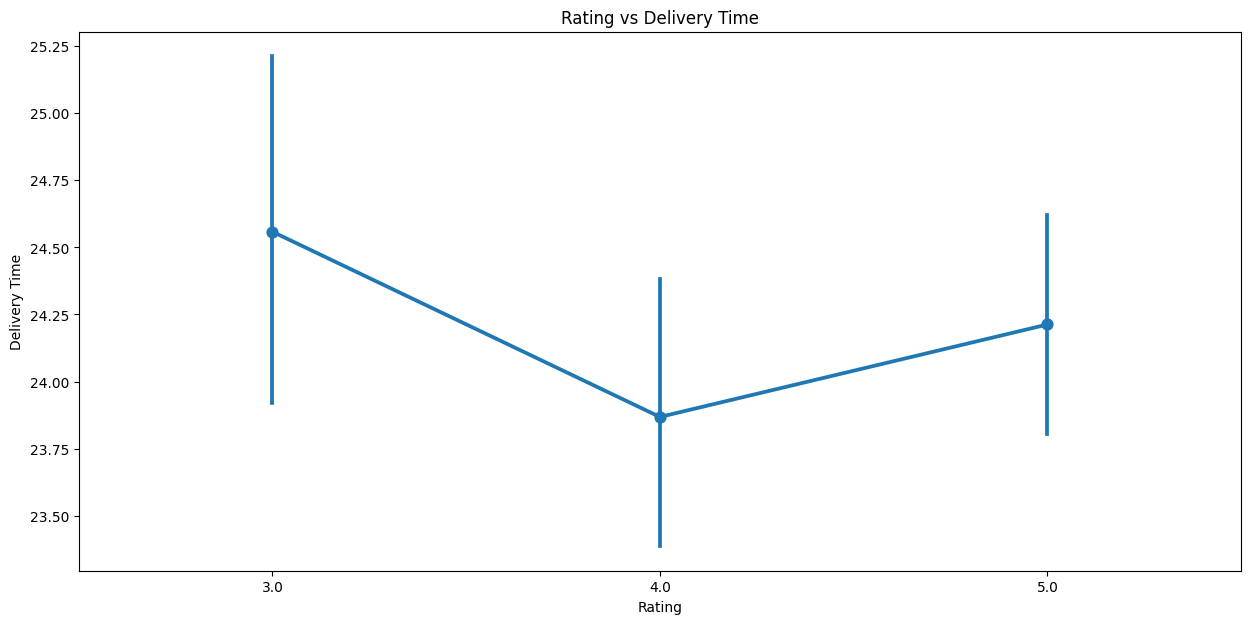

In [ ]:
plt.figure(figsize=(15, 7))
sns.pointplot(x = 'rating', y = 'delivery_time', data = df)
plt.title('Rating vs Delivery Time')
plt.xlabel('Rating')
plt.ylabel('Delivery Time')
plt.show()
# this code creates a point plot of the rating and the delivery time

#### Observation:

* *There is a weak linear relationship between rating and delivery time.*

* *The average delivery time for orders rated 4 is lower that the other ratings.*

#### Food Preparation Time and Rating  

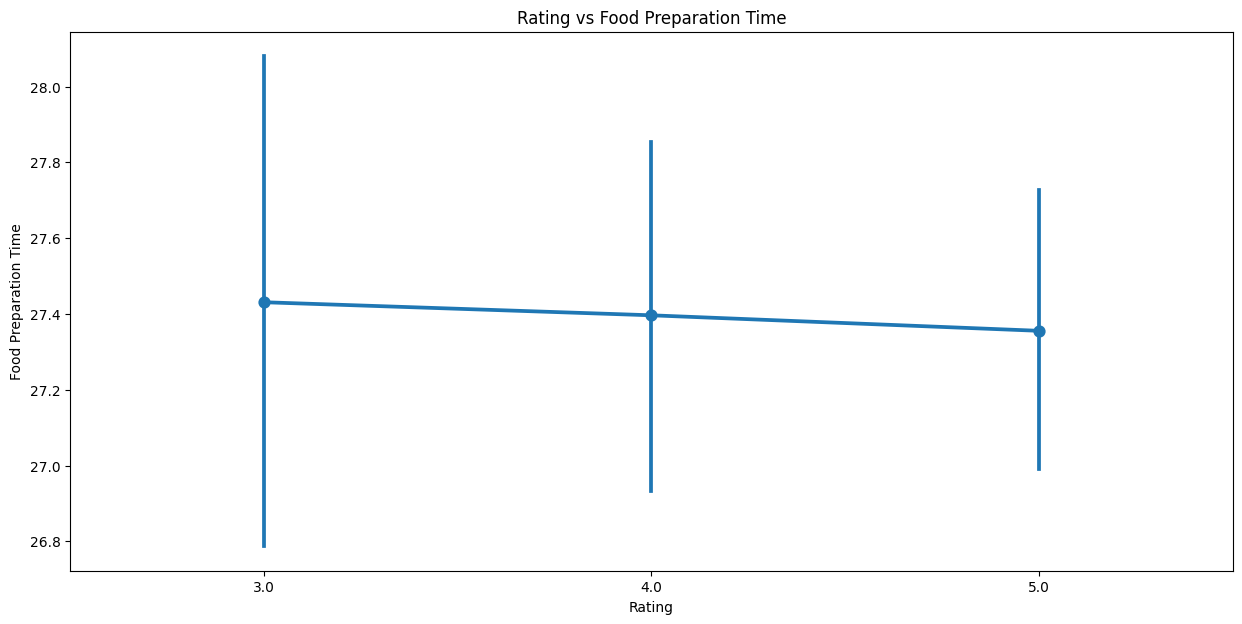

In [ ]:
plt.figure(figsize=(15, 7))
sns.pointplot(x = 'rating', y = 'food_preparation_time', data = df)  ## Complete the code to visualize the relationship between rating and food preparation time using pointplot
plt.title('Rating vs Food Preparation Time')
plt.xlabel('Rating')
plt.ylabel('Food Preparation Time')
plt.show()
# this code creates a point plot of the food preparation time and the rating

#### Observation:

* *There seems to be a slightly downwards slop between the time it takes the food to be prepared and the rating.*

* *However the line appears to be almost linear*

#### Rating and Cost of the Order

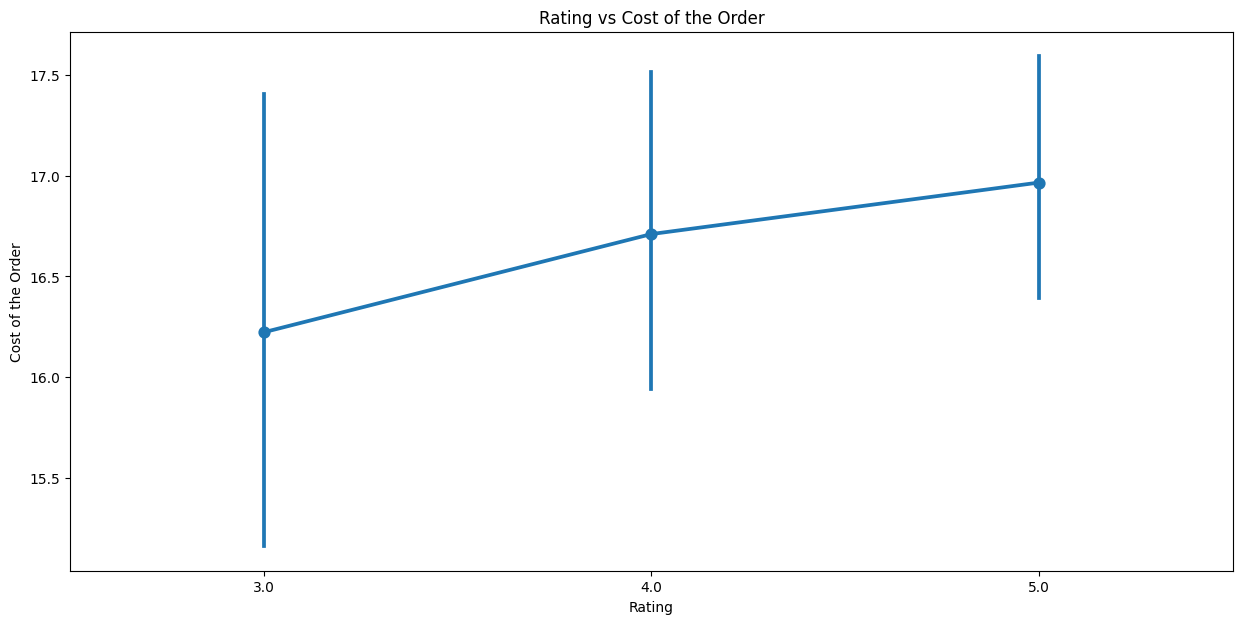

In [ ]:
plt.figure(figsize=(15, 7))
sns.pointplot(x = 'rating', y = 'cost_of_the_order', data = df)   ## Complete the code to visualize the relationship between rating and cost of the order using pointplot
plt.title('Rating vs Cost of the Order')
plt.xlabel('Rating')
plt.ylabel('Cost of the Order')
plt.show()
# this code creates a point plot of the rating and the cost of the order

#### Observation:

* *There seems to be an upwards trend between the cost of the order and the rating.*

* *The higher the rating, the higher the cost.*

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
restaurants_not_rated = df[df['rating'].isnull()]['restaurant_name'].unique() # this code filters the rated from the unrated restaurants
print(restaurants_not_rated) # this prints the output

['Hangawi' 'Blue Ribbon Sushi Izakaya' 'The Meatball Shop'
 'Big Wong Restaurant \x8c_¤¾Ñ¼' "Lucky's Famous Burgers" 'Sushi of Gari'
 'Shake Shack' 'Tortaria' 'Cafe Mogador' 'Otto Enoteca Pizzeria'
 'Vezzo Thin Crust Pizza' 'Sushi of Gari 46' '5 Napkin Burger' 'TAO'
 'Sushi Samba' 'Cafeteria' 'Blue Ribbon Fried Chicken' 'Bistango'
 'RedFarm Broadway' 'Blue Ribbon Sushi Bar & Grill' 'Westville Hudson'
 'Osteria Morini' 'Parm' 'RedFarm Hudson' "Xi'an Famous Foods"
 'Cafe Habana' 'Bareburger' 'Yama Japanese Restaurant'
 'Five Guys Burgers and Fries' 'Balthazar Boulangerie' 'CafÌ© China'
 'Blue Ribbon Sushi' 'Benihana' 'The Kati Roll Company' 'Five Leaves'
 'indikitch' 'Prosperity Dumpling' 'Momoya' 'Han Dynasty'
 'Mission Cantina' 'Delicatessen' "Sarabeth's East" "S'MAC"
 'Pepe Rosso To Go' 'Donburi-ya' "Vanessa's Dumplings"
 'Tarallucci e Vino Restaurant' 'Amma' 'Lantern Thai Kitchen' 'The Smile'
 "Vanessa's Dumpling House" "Bubby's " 'Dirty Bird To Go (archived)'
 'Chipotle Mexican Gril

In [ ]:
df['rating'] = df['rating'].astype(float) # this code changes the datatype of the rating column to float

In [ ]:
df.info() # this code checks the datatype of each column. this code is run here to verify if the rating column has been changed to float data type.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1162 non-null   float64
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 133.6+ KB


In [ ]:
# this code creates a dataframe with the names of the restaurants and their rating counts and prints the output.
restaurant_counts = df['restaurant_name'].value_counts().reset_index()
restaurant_counts.columns = ['restaurant_name', 'order_count']
print(restaurant_counts)

               restaurant_name  order_count
0                  Shake Shack          219
1            The Meatball Shop          132
2            Blue Ribbon Sushi          119
3    Blue Ribbon Fried Chicken           96
4                         Parm           68
..                         ...          ...
173                  Rye House            1
174             Hiroko's Place            1
175           Frank Restaurant            1
176            Sarabeth's West            1
177                 'wichcraft            1

[178 rows x 2 columns]


In [ ]:
restaurant_counts[restaurant_counts['order_count'] > 50] # this code displays the restaurants with rating counts higher than 50


,restaurant_name,order_count
0,Shake Shack,219
1,The Meatball Shop,132
2,Blue Ribbon Sushi,119
3,Blue Ribbon Fried Chicken,96
4,Parm,68
5,RedFarm Broadway,59
6,RedFarm Hudson,55


In [ ]:
# this code used the groupby function to find the mean of the restaurants
mean_rating_per_restaurant = df.groupby('restaurant_name')['rating'].mean().reset_index()
mean_rating_per_restaurant.columns = ['restaurant_name', 'mean_rating']
mean_rating_per_restaurant

,restaurant_name,mean_rating
0,'wichcraft,5.000000
1,12 Chairs,4.500000
2,5 Napkin Burger,4.000000
3,67 Burger,5.000000
4,Alidoro,NaN
...,...,...
173,Zero Otto Nove,4.000000
174,brgr,3.000000
175,da Umberto,5.000000
176,ilili Restaurant,4.153846


In [ ]:
restaurant_promo_criteria = pd.merge(restaurant_counts, mean_rating_per_restaurant, on='restaurant_name') # this code merges the two dataframes on restaurant_name
promotional_restaurants = restaurant_promo_criteria[(restaurant_promo_criteria['order_count'] > 50) & (restaurant_promo_criteria['mean_rating'] > 4)] # this filters the restaurants with more than 50 orders and also an average rating greater than 4
print(promotional_restaurants) # this prints the output

             restaurant_name  order_count  mean_rating
0                Shake Shack          219     4.278195
1          The Meatball Shop          132     4.511905
2          Blue Ribbon Sushi          119     4.219178
3  Blue Ribbon Fried Chicken           96     4.328125
4                       Parm           68     4.128205
5           RedFarm Broadway           59     4.243902
6             RedFarm Hudson           55     4.176471


#### Observations:

* *The restaurants that fulfill the criteria to receive the promotional offer are:*
  * *Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken, Parm, RedFarm Broadway, and RedFarm Hudson.*

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# this code creates a function with conditional statements for the 25% and 15%
def revenue(i):
    if i > 20:
        return i*0.25
    elif i > 5:
        return i*0.15
    else:
        return i*0
# this code applies the revenue calculated above to the cost of the order column and sums it up to generate the net revenue.
df['Revenue'] = df['cost_of_the_order'].apply(revenue)
net_revenue = df['Revenue'].sum()
net_revenue

np.float64(6166.303)

#### Observations:

* *The company generated a net revenue of 6,166,30 dollars.*

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
df['total_del_time'] = df['food_preparation_time'] + df['delivery_time'] # this code calculated the total delivery time by summing the food preparation time and the delivery time

In [ ]:
df # this displays the dataframe with the total_del_time column

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,Revenue,total_del_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20,7.6875,45
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23,1.8120,48
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.0,23,28,1.8345,51
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.0,25,15,7.3000,40
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.0,25,24,1.7385,49
...,...,...,...,...,...,...,...,...,...,...,...
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5.0,31,17,5.5775,48
1894,1477421,397537,The Smile,American,12.18,Weekend,5.0,31,19,1.8270,50
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,NaN,31,24,6.3050,55
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5.0,23,31,1.8270,54


In [ ]:
orders_more_than_60 = df[df['total_del_time'] > 60] # this code filters the orders that take more than 60 minutes to deliver
percentage_more_than_60 = (len(orders_more_than_60) / len(df)) * 100 # this code calculates the percentage of orders that take more than 60 minutes to deliver
percentage_more_than_60

10.537407797681771

#### Observations:
 * *About 10.53% of the orders take more than 60 minutes to be delivered from the time the order is placed.*

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
df.groupby(['day_of_the_week']) ['delivery_time'].mean() # this code checks the mean delivery time for weekdays and weekends.

,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


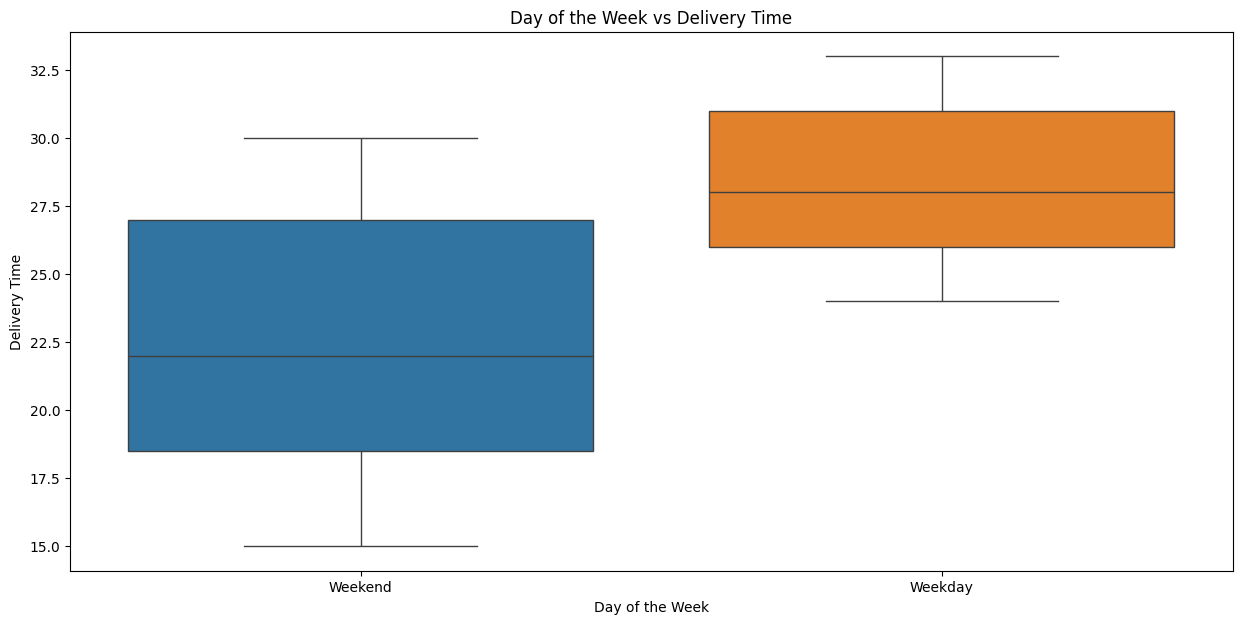

In [ ]:
plt.figure(figsize=(15,7)) # this code creates a plot with size 15, 7
sns.boxplot(x = 'day_of_the_week', y = 'delivery_time', data = df, hue = 'day_of_the_week') # this code creates a box plot of the day of the week and the delivery time and show each bar in a different colour
plt.title('Day of the Week vs Delivery Time') # this displays the title of the plot as specified in the parenthesis
plt.xlabel('Day of the Week') # this labels the x axis as 'Day of the Week'
plt.ylabel('Delivery Time') # this labels the y axis as 'Delivery Time'
plt.show() # this displays the boxplot

#### Observations:
 * *The average delivery time is higher on weekdays than on weekends.*

* *There seem to be a lot more orders on weekends*

* *While there are more orders on weekends, it takes more time for the orders to be delivered on weekdays.*

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:

* Almost all the columns in the dataset had all their values except for the rating column.


**Price**

* Majority of the orders cost low which may seem optimal for customers.

* However, there was a slighlty significant portion or orders that cost more thatn 20 dollars


**Customer Preference**
* A significant proportion of the rating column had missing values and being quick to treat with the mean or median will likely cause skewness in the data and affect any further analysis.
In addition, food and restaurant ratings are subjective and reflect each individual's preference and inputting values may be a poor reflection the customer's choice.

* A lot more customers prefer American, Japanese and Italian cuisine. Also, there is a lot of preference for Shake Shack, The Meatball Shop and Blue Ribbon Sushi restaurants.

* There are a lot more orders placed on the weekends.


**Customer Wait Time**

* The analysis seems to suggest that customers do not have to wait for longer periods to receive their food.

* Notably, the total time it takes for the food to be delivered after the order is place is almost 60 minutes.

* Longer delivery times may be due to several factors including the distance between the restaurant and the delivery location, however that information is not provided in the data.

* However, it is necessary to enhance efficiency in this area and improve the wait times.

### Recommendations:

*  It is imperative to closely monitor the data collection process to minimize errors and missing value since this can signigicantly impact the analysis.


* The price can be tested for a period to determine the most appropriate range to enhance customer patronage.
In addition, the price should not fall too low or rise too high to affect the FoodHub.


* Customer preference for cuisine and specific restaurants should be taken into consideration. Market strategies should target these restaurants and cuisines.
In addition, these restaurants should be given feedback in order for them to maintain a good stand to enhance customer patronage.
Also, the cuisine preferences should be shared with the restaurants so they can incorporate more in their menus.


* The wait time should be improved to enhance customer experience. It is important to consider the distance between the restaurant and the delivery location and find alternative and faster routes.
Also, the restaurants should be given feedback so that they can improve their food preparation time.


* Discounts and loyalty programs are great incentives for customers to continue patronizing the services. These should be continued.


---